In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
original_data = pd.read_csv("responses_22.csv")

In [3]:
# Function to create dictionary for renaming columns
def edit_cols(cols):
    nudge_num = 1
    risk_num = 1
    col_dict = {}
    for i, OLD_col in enumerate(cols):
        col = OLD_col.lower().strip()
        if col[0].isnumeric():
            first_word = col.split(" ")[1]
            if first_word == "select":
                NEW_col = "risk_" + str(risk_num)
                risk_num += 1
            elif first_word == "this":
                NEW_col = "nudge_" + str(nudge_num)
                nudge_num += 1
        elif "age" in col:
            NEW_col = "age"
        elif "parents" in col:
            NEW_col = "parent_edu"
        elif "income" in col:
            NEW_col = "income"
        elif col == "what do you think this survey was about?":
            NEW_col = "participant_bias"
        elif "questions" in col:
            NEW_col = "comments"
        else:
            NEW_col = col
        
        col_dict[OLD_col] = NEW_col
    
    return col_dict

In [4]:
# Create dictionary for column name mapping; rename columns
col_dict = edit_cols(original_data.columns)
data = original_data.rename(columns=col_dict)

# Basic data cleaning
data = data.map(lambda x: x.strip()[-1] if "option" in str(x).lower() else x)

gender_dict = {"Man": "M", "Woman": "W", "Non-binary": "NB"}
data['gender'] = data['gender'].map(gender_dict)

data.replace({"Grad Student": "Graduate", "I'm not a student": "Non-Student", "Prefer not to specify": "PNTS"}, inplace=True)

for col in data.columns:
    if "nudge" in col:
        data[col] = data[col].map(lambda x: x if x == "B" else "none")

data['participant'] = ["P" + str(val) for val in np.arange(len(data)) + 1]

In [5]:
data.head()

,timestamp,gender,year,age,parent_edu,income,risk_1,risk_2,nudge_1,nudge_2,...,nudge_6,nudge_7,risk_9,nudge_8,risk_10,nudge_9,nudge_10,participant_bias,comments,participant
0,2/28/2026 20:38:36,M,Senior,22-25,Masters or professional degree,PNTS,A,A,none,none,...,none,none,A,none,A,none,none,Your family background and its implication on...,Cool stuff,P1
1,2/28/2026 20:44:12,M,Junior,18-21,Masters or professional degree,"$250,000+",A,A,none,none,...,B,B,A,B,B,B,B,A supposed correlation between financial choic...,I have OCD,P2
2,2/28/2026 20:44:32,M,Senior,22-25,Undergraduate degree,"$100,000-200,000",B,B,B,B,...,B,none,B,B,B,none,B,s,NaN,P3
3,3/1/2026 12:56:50,W,Junior,18-21,Masters or professional degree,"$250,000+",B,B,B,B,...,B,none,A,none,B,none,B,Risk tolerance,Too many qs; wasn’t thinking as critically at ...,P4
4,3/1/2026 13:02:04,W,Freshman,18-21,Undergraduate degree,"$100,000-200,000",B,B,B,B,...,B,none,B,B,A,B,none,.,NaN,P5


In [6]:
# Create DataFrame to store question information
questions_df = pd.DataFrame(index = [col for col in data.columns if "risk" in col or "nudge" in col])

# Extract and store the opetions for each question
for key, val in col_dict.items():
    if "risk" in val or "nudge" in val:
        for i in key.strip().split("\n"):
            if "option a" in i.lower():
                questions_df.loc[val, 'Option_A'] = i.split(":")[-1].strip()
            elif "option b" in i.lower():
                questions_df.loc[val, 'Option_B'] = i.split(":")[-1].strip()

# Indicate whic option is riskier (manually determined) 
risky_choice = np.array(["A", "A", "A", "A", "B", "B", "B", "B", "A", "B", "B", "NaN", "A", "A", "NaN", "A", "A", "A", "A", "A"])
questions_df['risky_choice'] = risky_choice

# Indicate direction of nudge (if applicable)
for question in questions_df.index:
    if "nudge" in question:
        if questions_df.loc[question, 'risky_choice'] == "A":
            questions_df.loc[question, 'nudge_direction'] = "to_risky"
        else:
            questions_df.loc[question, 'nudge_direction'] = "to_safe"
    else:   
        questions_df.loc[question, 'nudge_direction'] = "none"

In [7]:
questions_df

,Option_A,Option_B,risky_choice,nudge_direction
risk_1,"40% chance of $300, 60% chance of nothing.",100% chance of $110,A,none
risk_2,"40% chance of $200, 60% chance of nothing.",100% chance of $80,A,none
nudge_1,"40% chance of $300, 60% chance of nothing.",100% chance of $110,A,to_risky
nudge_2,"40% chance of $200, 60% chance of nothing.",100% chance of $80,A,to_risky
risk_3,100% chance of $50,"50% chance of $100, 50% chance of nothing",B,none
nudge_3,100% chance of $50,"50% chance of $100, 50% chance of nothing",B,to_safe
risk_4,100% chance of $20,"50% chance of $45, 50% chance of nothing",B,none
risk_5,100% chance of $220,"50% chance of $400, 50% chance of $40",B,none
risk_6,"25% chance of $800, 75% chance of $100",100% chance of $310,A,none
nudge_4,100% chance of $20,"50% chance of $45, 50% chance of nothing",B,to_safe


In [8]:
def format_outcomes(col):
    choices = []
    for choice in questions_df[col]:
        outcome_list = choice.split(",")
        outcomes = []
        for outcome in outcome_list:
            outcome = re.sub(r'[^\w\s%$]', "", outcome)
            outcome = outcome.strip().split(" ")
            formatted_outcome = []
            for item in outcome:
                if item.endswith("%"):
                    p = item.strip("%")
                    p = float(p) / 100
                    formatted_outcome.append(p)
                elif item.startswith("$"):
                    v = item.strip("$")
                    v = float(v)
                    formatted_outcome.append(v)

            if len(formatted_outcome) != 2:
                formatted_outcome.append(0)
            outcomes.append(formatted_outcome)
        choices.append(outcomes)
    return choices


In [9]:
questions_df["outcomes_A"] = format_outcomes("Option_A")
questions_df["outcomes_B"] = format_outcomes("Option_B")

In [10]:
shannon_entropy = lambda x: x * np.log2(x) if x > 0 else 0

def calculate_entropy(col):
    entropy_col = []
    for outcomes in questions_df[col]:
        p_list = []
        for outcome in outcomes:
            p_list.append(outcome[0])
        shannon = map(shannon_entropy, p_list)
        entropy_sum = -1 * sum(shannon)
        entropy_col.append(entropy_sum)
    return entropy_col

questions_df["entropy_A"] = calculate_entropy("outcomes_A")
questions_df["entropy_B"] = calculate_entropy("outcomes_B")

In [11]:
questions_df

,Option_A,Option_B,risky_choice,nudge_direction,outcomes_A,outcomes_B,entropy_A,entropy_B
risk_1,"40% chance of $300, 60% chance of nothing.",100% chance of $110,A,none,"[[0.4, 300.0], [0.6, 0]]","[[1.0, 110.0]]",0.970951,-0.000000
risk_2,"40% chance of $200, 60% chance of nothing.",100% chance of $80,A,none,"[[0.4, 200.0], [0.6, 0]]","[[1.0, 80.0]]",0.970951,-0.000000
nudge_1,"40% chance of $300, 60% chance of nothing.",100% chance of $110,A,to_risky,"[[0.4, 300.0], [0.6, 0]]","[[1.0, 110.0]]",0.970951,-0.000000
nudge_2,"40% chance of $200, 60% chance of nothing.",100% chance of $80,A,to_risky,"[[0.4, 200.0], [0.6, 0]]","[[1.0, 80.0]]",0.970951,-0.000000
risk_3,100% chance of $50,"50% chance of $100, 50% chance of nothing",B,none,"[[1.0, 50.0]]","[[0.5, 100.0], [0.5, 0]]",-0.000000,1.000000
nudge_3,100% chance of $50,"50% chance of $100, 50% chance of nothing",B,to_safe,"[[1.0, 50.0]]","[[0.5, 100.0], [0.5, 0]]",-0.000000,1.000000
risk_4,100% chance of $20,"50% chance of $45, 50% chance of nothing",B,none,"[[1.0, 20.0]]","[[0.5, 45.0], [0.5, 0]]",-0.000000,1.000000
risk_5,100% chance of $220,"50% chance of $400, 50% chance of $40",B,none,"[[1.0, 220.0]]","[[0.5, 400.0], [0.5, 40.0]]",-0.000000,1.000000
risk_6,"25% chance of $800, 75% chance of $100",100% chance of $310,A,none,"[[0.25, 800.0], [0.75, 100.0]]","[[1.0, 310.0]]",0.811278,-0.000000
nudge_4,100% chance of $20,"50% chance of $45, 50% chance of nothing",B,to_safe,"[[1.0, 20.0]]","[[0.5, 45.0], [0.5, 0]]",-0.000000,1.000000


In [12]:
# Keep in case, but this shis is useless for now
df = questions_df.copy().reset_index()
for i, (entropy_A, entropy_B) in enumerate(zip(df['entropy_A'], df['entropy_B'])):
    if entropy_A == entropy_B:
        outcomes_A = np.array(df.loc[i, "outcomes_A"])
        outcomes_B = np.array(df.loc[i, "outcomes_B"])

        idx_A = outcomes_A.flatten().argmax() // 2
        idx_B = outcomes_B.flatten().argmax() // 2

        max_A = shannon_entropy(outcomes_A[idx_A][0])
        max_B = shannon_entropy(outcomes_B[idx_B][0])
        
        df.at[i, 'entropy_A'] = max_A
        df.at[i, 'entropy_B'] = max_B
    else:
        continue

In [13]:
# Create DataFrame to store participant response classes to risk and nudge questions
risk_df = data[questions_df.index.to_list() + ["participant"]].copy()

# Classify participant responses as "R" (risky) or "S" (safe); add nudge acceptance column for nudge questions (1 for acceptance, 0 for rejection)
for col in risk_df.columns:
    if col != "participant":
        risky_choice = questions_df.loc[col, 'risky_choice']
        if "risk" in col:
            risk_df.loc[:, col] = risk_df[col].map(lambda x: "R" if x == risky_choice else "S")
        elif "nudge" in col:
            risk_df.loc[:, f"{col}_accept"] = risk_df[col].map(lambda x: 1 if x == 'none' else 0)
            risk_df.loc[:, col] = risk_df[col].map(lambda x: x if x == "B" else "A").map(lambda x: "R" if x == risky_choice else "S")

risk_df["pure_risk_preference"] = risk_df[[col for col in risk_df.columns if "risk" in col]].apply(lambda x: sum(x == "R")/10, axis=1)
risk_df["nudge_susceptibility"] = risk_df[[col for col in risk_df.columns if "nudge" in col and "accept" in col]].apply(lambda x: sum(x == 1)/10, axis=1)


# risk_df["nudge_susceptibility_to_risk"] = risk_df[[col for col in risk_df.columns if ]]

In [14]:
to_risky = questions_df[questions_df['nudge_direction'] == "to_risky"].index.to_list()
to_risky

['nudge_1', 'nudge_2', 'nudge_6', 'nudge_8', 'nudge_9', 'nudge_10']

In [15]:
risk_df.head()

,risk_1,risk_2,nudge_1,nudge_2,risk_3,nudge_3,risk_4,risk_5,risk_6,nudge_4,...,nudge_3_accept,nudge_4_accept,nudge_5_accept,nudge_6_accept,nudge_7_accept,nudge_8_accept,nudge_9_accept,nudge_10_accept,pure_risk_preference,nudge_susceptibility
0,R,R,R,R,S,S,R,S,S,S,...,1,1,1,1,1,1,1,1,0.5,1.0
1,R,R,R,R,R,R,S,R,S,R,...,0,0,1,0,0,0,0,0,0.5,0.3
2,S,S,S,S,S,S,S,S,S,S,...,1,1,1,0,1,0,1,0,0.0,0.5
3,S,S,S,S,S,S,R,S,S,R,...,1,0,1,0,1,1,1,0,0.2,0.5
4,S,S,S,S,R,S,R,S,S,S,...,1,1,1,0,1,0,0,1,0.3,0.5


In [16]:
risk_df['pure_risk_preference'].describe()

count    22.000000
mean      0.254545
std       0.150324
min       0.000000
25%       0.200000
50%       0.200000
75%       0.375000
max       0.500000
Name: pure_risk_preference, dtype: float64

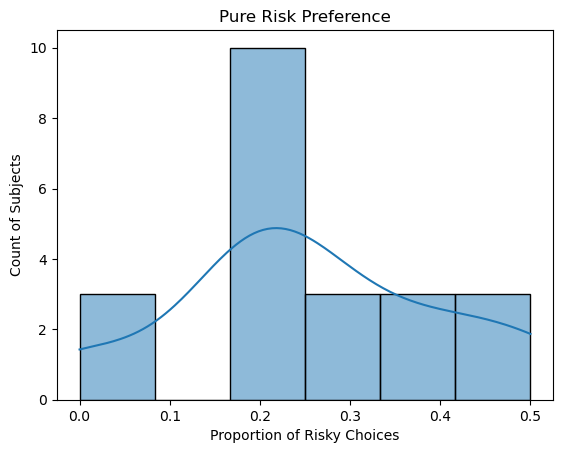

In [69]:
sns.histplot(risk_df['pure_risk_preference'], color='C0', kde=True)
plt.title('Pure Risk Preference')
plt.xlabel('Proportion of Risky Choices')
plt.ylabel('Count of Subjects')
plt.savefig('Pure Risk Preference.png', dpi=300, bbox_inches='tight')
plt.show()

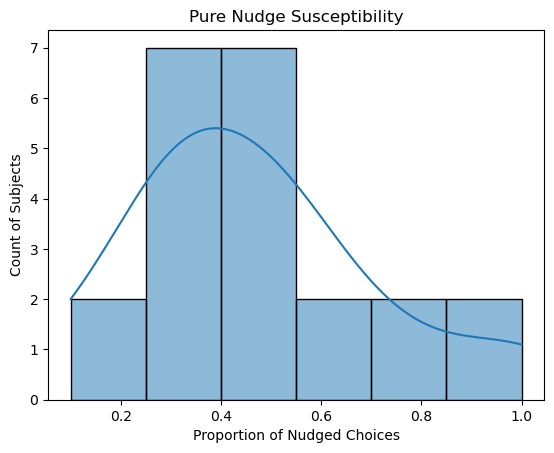

In [70]:
sns.histplot(risk_df['nudge_susceptibility'], color='C0', kde=True)
plt.title('Pure Nudge Susceptibility')
plt.xlabel('Proportion of Nudged Choices')
plt.ylabel('Count of Subjects')
plt.savefig('Pure Nudge Susceptibility.png', dpi=300, bbox_inches='tight')
plt.show()

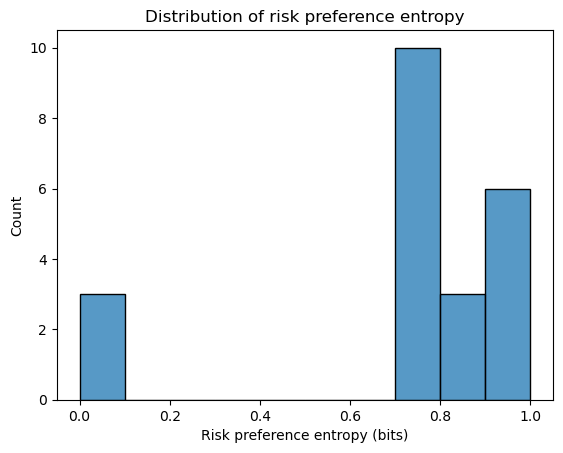

In [19]:
# participant-level Shannon entropy of risky vs safe choices
risk_df["risk_preference_entropy"] = risk_df["pure_risk_preference"].apply(
    lambda p: -(shannon_entropy(p) + shannon_entropy(1 - p))
)

sns.histplot(risk_df["risk_preference_entropy"], bins=10, kde=False, color='C0')
plt.xlabel("Risk preference entropy (bits)")
plt.ylabel("Count")
plt.title("Distribution of risk preference entropy")
plt.show()

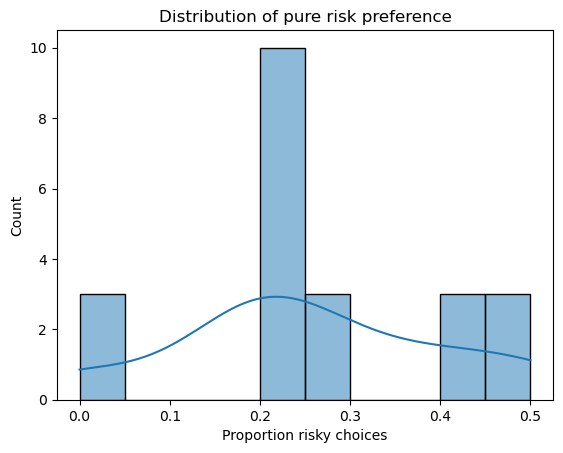

In [20]:
sns.histplot(risk_df["pure_risk_preference"], bins=10, kde=True, color='C0')
plt.xlabel("Proportion risky choices")
plt.ylabel("Count")
plt.title("Distribution of pure risk preference")
plt.show()

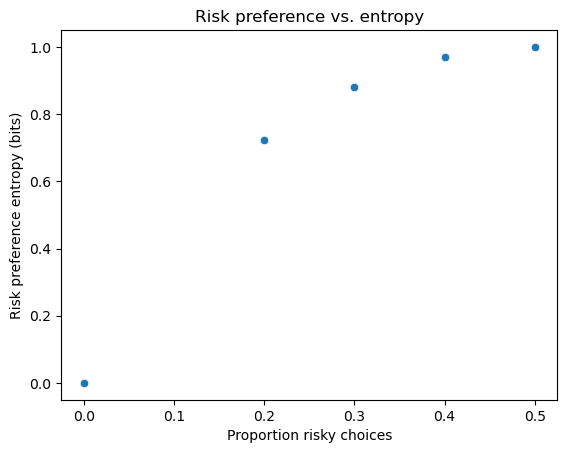

In [21]:
sns.scatterplot(data=risk_df, x="pure_risk_preference", y="risk_preference_entropy")
plt.xlabel("Proportion risky choices")
plt.ylabel("Risk preference entropy (bits)")
plt.title("Risk preference vs. entropy")
plt.show()

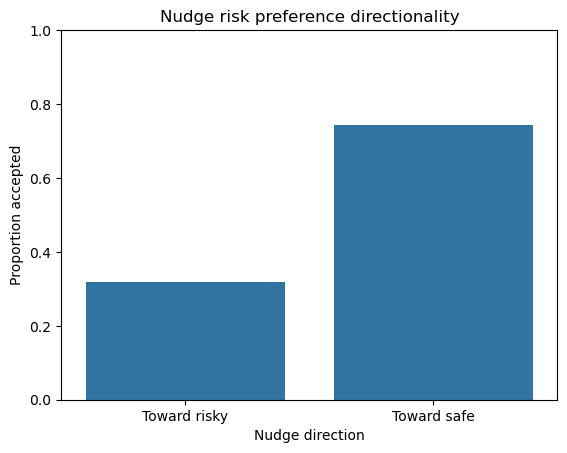

In [61]:
# keep only valid nudge questions (exclude ones where risky_choice was not coded)
valid_nudges = questions_df[
    questions_df.index.str.contains("nudge") &
    questions_df["risky_choice"].isin(["A", "B"])
]

to_risky = valid_nudges[valid_nudges["nudge_direction"] == "to_risky"].index.to_list()
to_safe  = valid_nudges[valid_nudges["nudge_direction"] == "to_safe"].index.to_list()

# overall proportion of accepted nudges in each direction
plot_df = pd.DataFrame({
    "direction": ["Toward risky", "Toward safe"],
    "proportion_accepted": [
        risk_df[[f"{col}_accept" for col in to_risky]].to_numpy().mean(),
        risk_df[[f"{col}_accept" for col in to_safe]].to_numpy().mean()
    ]
})

sns.barplot(data=plot_df, x="direction", y="proportion_accepted", color="C0")
plt.ylim(0, 1)
plt.xlabel("Nudge direction")
plt.ylabel("Proportion accepted")
plt.title("Nudge risk preference directionality")
plt.savefig('Nudge risk preference directionality.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# valid nudge questions only
valid_nudges = questions_df[
    questions_df.index.str.contains("nudge") &
    questions_df["risky_choice"].isin(["A", "B"])
]

to_risky = valid_nudges[valid_nudges["nudge_direction"] == "to_risky"].index.to_list()
to_safe  = valid_nudges[valid_nudges["nudge_direction"] == "to_safe"].index.to_list()

# participant-level proportion of accepted nudges in each direction
risk_df["accept_to_risky"] = risk_df[[f"{col}_accept" for col in to_risky]].sum(axis=1)
risk_df["accept_to_safe"]  = risk_df[[f"{col}_accept" for col in to_safe]].sum(axis=1)

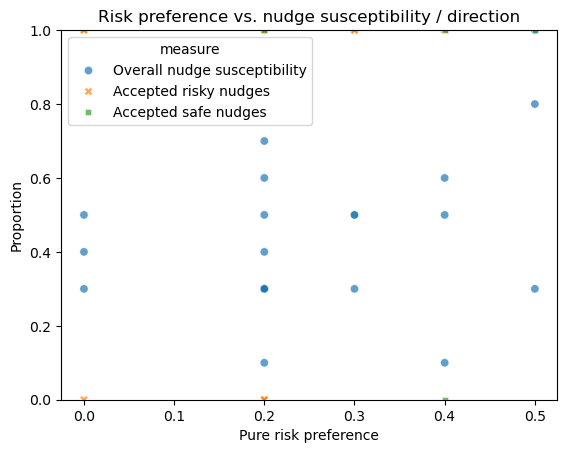

In [32]:
# risk preference x nudge susceptibility

# risk pref x risky nudges
# risk pref x safe nudges

# one point per participant per metric
plot_df = pd.concat([
    risk_df[["pure_risk_preference", "nudge_susceptibility"]]
        .rename(columns={"nudge_susceptibility": "y"})
        .assign(measure="Overall nudge susceptibility", participant=risk_df.index),

    risk_df[["pure_risk_preference", "accept_to_risky"]]
        .rename(columns={"accept_to_risky": "y"})
        .assign(measure="Accepted risky nudges", participant=risk_df.index),

    risk_df[["pure_risk_preference", "accept_to_safe"]]
        .rename(columns={"accept_to_safe": "y"})
        .assign(measure="Accepted safe nudges", participant=risk_df.index)
], ignore_index=True)

sns.scatterplot(
    data=plot_df,
    x="pure_risk_preference",
    y="y",
    hue="measure",
    style="measure",
    alpha=0.7
)

plt.xlabel("Pure risk preference")
plt.ylabel("Proportion")
plt.title("Risk preference vs. nudge susceptibility / direction")
plt.ylim(0, 1)
plt.show()

In [33]:
risk_df.head()

,risk_1,risk_2,nudge_1,nudge_2,risk_3,nudge_3,risk_4,risk_5,risk_6,nudge_4,...,nudge_7_accept,nudge_8_accept,nudge_9_accept,nudge_10_accept,pure_risk_preference,nudge_susceptibility,risk_preference_entropy,accept_to_risky,accept_to_safe,nudge_directionality
0,R,R,R,R,S,S,R,S,S,S,...,1,1,1,1,0.5,1.0,1.000000,6,3,0.083340
1,R,R,R,R,R,R,S,R,S,R,...,0,0,0,0,0.5,0.3,1.000000,2,1,0.027780
2,S,S,S,S,S,S,S,S,S,S,...,1,0,1,0,0.0,0.5,-0.000000,1,3,-0.124993
3,S,S,S,S,S,S,R,S,S,R,...,1,1,1,0,0.2,0.5,0.721928,2,2,-0.027773
4,S,S,S,S,R,S,R,S,S,S,...,1,0,0,1,0.3,0.5,0.881291,1,3,-0.124993


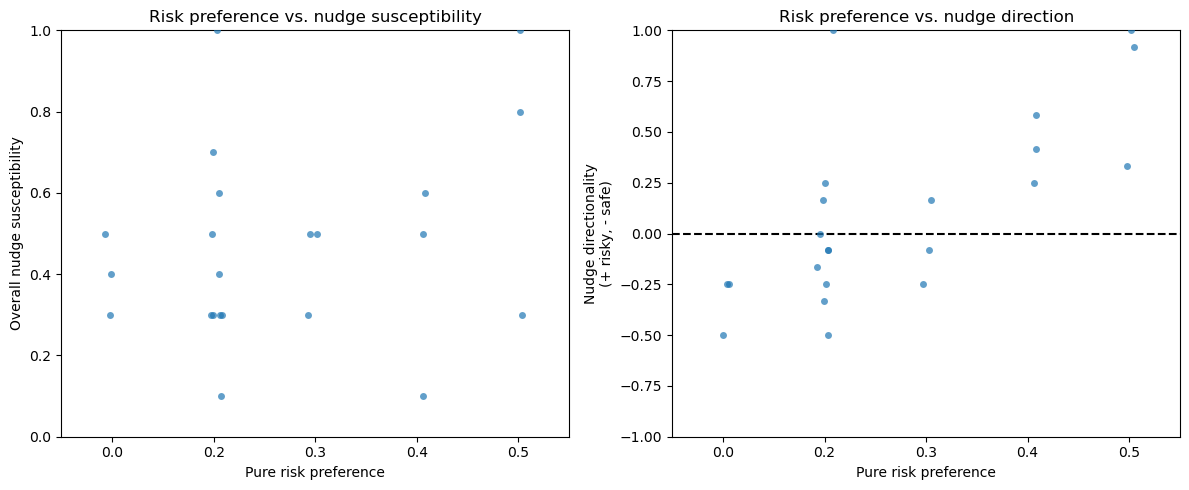

In [34]:
risk_df["nudge_directionality"] = 0.25*risk_df["accept_to_risky"] - 0.16666*risk_df["accept_to_safe"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.stripplot(
    data=risk_df,
    x="pure_risk_preference",
    y="nudge_susceptibility",
    jitter=0.08,
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_xlabel("Pure risk preference")
axes[0].set_ylabel("Overall nudge susceptibility")
axes[0].set_title("Risk preference vs. nudge susceptibility")
axes[0].set_ylim(0, 1)

sns.stripplot(
    data=risk_df,
    x="pure_risk_preference",
    y="nudge_directionality",
    jitter=0.08,
    alpha=0.7,
    ax=axes[1]
)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("Pure risk preference")
axes[1].set_ylabel("Nudge directionality\n(+ risky, - safe)")
axes[1].set_title("Risk preference vs. nudge direction")
axes[1].set_ylim(-1, 1)

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Nudge Susceptibility')

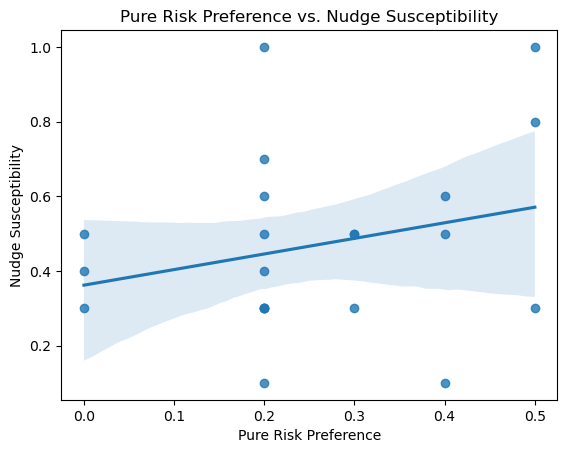

In [52]:
sns.regplot(
    data=risk_df,
    x="pure_risk_preference",
    y="nudge_susceptibility"
)
plt.title('Pure Risk Preference vs. Nudge Susceptibility')
plt.xlabel('Pure Risk Preference')
plt.ylabel('Nudge Susceptibility')

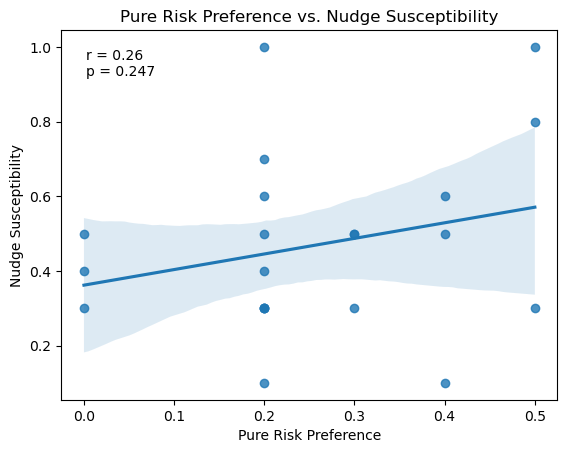

In [59]:
from scipy.stats import pearsonr

sns.regplot(
    data=risk_df,
    x="pure_risk_preference",
    y="nudge_susceptibility"
)

r, p = pearsonr(risk_df["pure_risk_preference"], risk_df["nudge_susceptibility"])
p_text = f"{p:.3f}" if p >= 0.001 else "< 0.001"

plt.text(
    0.05, 0.95,
    f"r = {r:.2f}\np = {p_text}",
    transform=plt.gca().transAxes,
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

plt.title('Pure Risk Preference vs. Nudge Susceptibility')
plt.xlabel('Pure Risk Preference')
plt.ylabel('Nudge Susceptibility')
plt.savefig('Pure Risk Preference vs. Nudge Susceptibility.png', dpi=300, bbox_inches='tight')
plt.show()

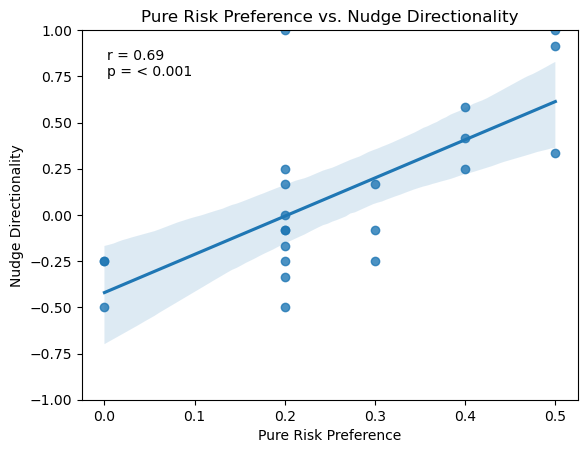

In [60]:
from scipy.stats import pearsonr

sns.regplot(
    data=risk_df,
    x="pure_risk_preference",
    y="nudge_directionality"
)

r, p = pearsonr(risk_df["pure_risk_preference"], risk_df["nudge_directionality"])
p_text = f"{p:.3f}" if p >= 0.001 else "< 0.001"

plt.text(
    0.05, 0.95,
    f"r = {r:.2f}\np = {p_text}",
    transform=plt.gca().transAxes,
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

plt.title('Pure Risk Preference vs. Nudge Directionality')
plt.xlabel('Pure Risk Preference')
plt.ylabel('Nudge Directionality')
plt.ylim([-1,1])
plt.savefig('Pure Risk Preference vs. Nudge Directionality.png', dpi=300, bbox_inches='tight')
plt.show()

(-1.0, 1.0)

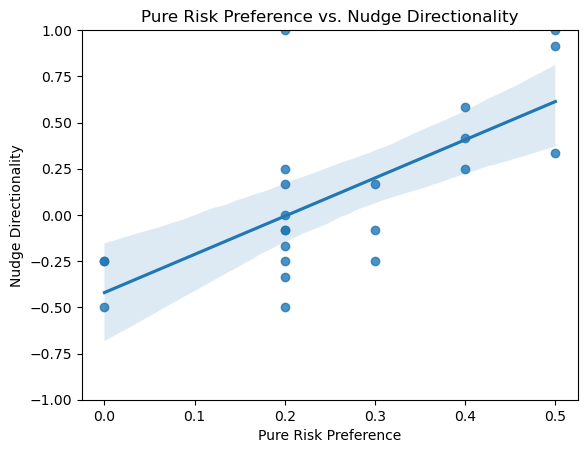

In [50]:
sns.regplot(
    data=risk_df,
    x="pure_risk_preference",
    y="nudge_directionality"
)
plt.title('Pure Risk Preference vs. Nudge Directionality')
plt.xlabel('Pure Risk Preference')
plt.ylabel('Nudge Directionality')
plt.ylim([-1,1])

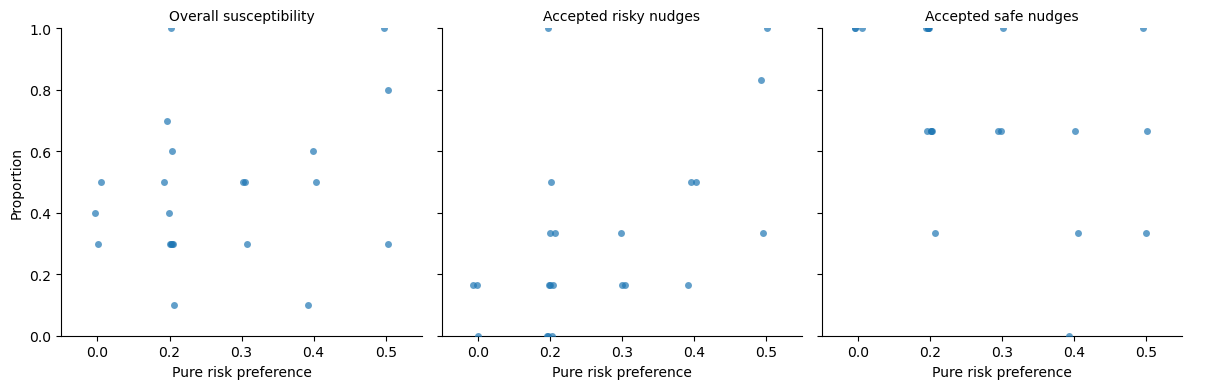

In [28]:
plot_df = pd.concat([
    risk_df[["pure_risk_preference", "nudge_susceptibility"]]
        .rename(columns={"nudge_susceptibility": "value"})
        .assign(measure="Overall susceptibility"),

    risk_df[["pure_risk_preference", "accept_to_risky"]]
        .rename(columns={"accept_to_risky": "value"})
        .assign(measure="Accepted risky nudges"),

    risk_df[["pure_risk_preference", "accept_to_safe"]]
        .rename(columns={"accept_to_safe": "value"})
        .assign(measure="Accepted safe nudges")
], ignore_index=True)

g = sns.catplot(
    data=plot_df,
    x="pure_risk_preference",
    y="value",
    col="measure",
    kind="strip",
    jitter=0.08,
    alpha=0.7,
    height=4,
    aspect=1
)

g.set_axis_labels("Pure risk preference", "Proportion")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.set_ylim(0, 1)

plt.show()